# Tarea 14 — Ecuaciones Diferenciales de Orden Superior y Método de Disparo

**Curso:** Astrofísica Computacional 2026-I

Este notebook resuelve los dos ejemplos de clase sobre la conversión de ODEs de segundo orden a sistemas de primer orden y su resolución numérica.

---

## 1. Aplicación: Método de Euler para sistema de primer orden

Tenemos la siguiente ODE de segundo orden reescrita como dos de primer orden:

70658 \frac{du}{dr} = z = f_1(r, u, z) 70658
70658 \frac{dz}{dr} = -\frac{1}{r}z + \frac{u}{r^2} = f_2(r, u, z) 70658

Con condiciones iniciales en  = 13$:
- (13) = 0.01007$
- (13) \approx -0.00034$

Se nos pide usar el método de Euler con 4 segmentos y  = 1.75$.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parametros del problema 1
r0 = 13.0
u0 = 0.01007
z0 = -0.00034
h = 1.75
n_segmentos = 4

# Definicion de las derivadas
def f1(r, u, z):
    return z

def f2(r, u, z):
    return - (1.0 / r) * z + (u / r**2)

# Arreglos para guardar los resultados
r_vals = np.zeros(n_segmentos + 1)
u_vals = np.zeros(n_segmentos + 1)
z_vals = np.zeros(n_segmentos + 1)

r_vals[0] = r0
u_vals[0] = u0
z_vals[0] = z0

print("i | r_i   | u_i        | z_i        | f1(r,u,z)  | f2(r,u,z)")
print("--|-------|------------|------------|------------|-----------")

# Metodo de Euler
for i in range(n_segmentos):
    r = r_vals[i]
    u = u_vals[i]
    z = z_vals[i]
    
    k1_u = f1(r, u, z)
    k1_z = f2(r, u, z)
    
    print(f"{i} | {r:5.2f} | {u:.8f} | {z:.8f} | {k1_u:.8f} | {k1_z:.8f}")
    
    r_vals[i+1] = r + h
    u_vals[i+1] = u + k1_u * h
    z_vals[i+1] = z + k1_z * h

# Imprimir el ultimo paso
print(f"{n_segmentos} | {r_vals[-1]:5.2f} | {u_vals[-1]:.8f} | {z_vals[-1]:.8f} |    ---     |    ---    ")


i | r_i   | u_i        | z_i        | f1(r,u,z)  | f2(r,u,z)
--|-------|------------|------------|------------|-----------
0 | 13.00 | 0.01007000 | -0.00034000 | -0.00034000 | 0.00008574
1 | 14.75 | 0.00947500 | -0.00018996 | -0.00018996 | 0.00005643
2 | 16.50 | 0.00914258 | -0.00009120 | -0.00009120 | 0.00003911
3 | 18.25 | 0.00898297 | -0.00002276 | -0.00002276 | 0.00002822
4 | 20.00 | 0.00894313 | 0.00002662 |    ---     |    ---    


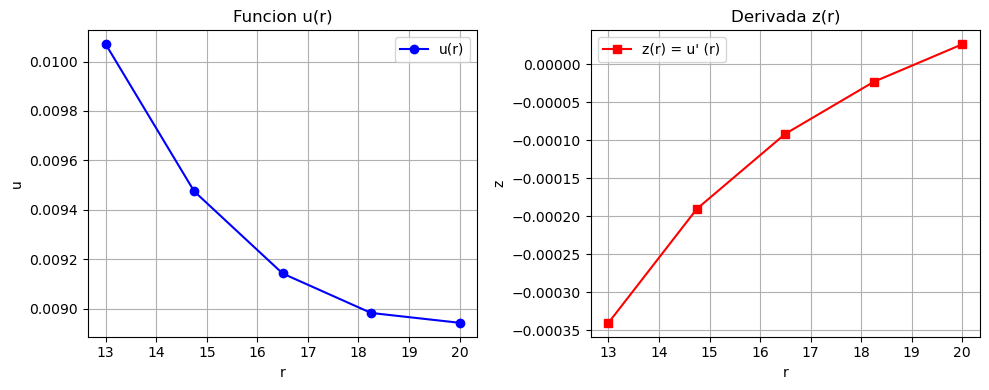

In [3]:
# Graficamos la solucion
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(r_vals, u_vals, "o-b", label="u(r)")
plt.title("Funcion u(r)")
plt.xlabel("r")
plt.ylabel("u")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(r_vals, z_vals, "s-r", label="z(r) = u' (r)")
plt.title("Derivada z(r)")
plt.xlabel("r")
plt.ylabel("z")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

---

## 2. Ejemplo 1: Ecuación de segundo orden con término forzado

Reescribir y resolver la siguiente ODE de segundo orden:

70658 3\frac{d^2y}{dx^2} + 2\frac{dy}{dx} + 5y = e^{-x}, \quad y(0)=5, \quad y'(0)=7 70658

Haciendo la sustitución  = \frac{dy}{dx}$, obtenemos el sistema:

70658 \frac{dy}{dx} = z, \quad y(0)=5 70658
70658 \frac{dz}{dx} = \frac{1}{3}(e^{-x} - 2z - 5y), \quad z(0)=7 70658

A continuación resolvemos este sistema en el intervalo  \in [0, 5]$ usando **Runge-Kutta de 4to orden (RK4)** y comparamos con **Euler**.

In [4]:
# Parametros del problema 2
x0 = 0.0
xf = 5.0
h2 = 0.1
N2 = int((xf - x0) / h2)

x_vals = np.linspace(x0, xf, N2+1)

y0 = 5.0
z0 = 7.0

# Definicion del sistema de ecuaciones
def dy_dx(x, y, z):
    return z

def dz_dx(x, y, z):
    return (np.exp(-x) - 2.0*z - 5.0*y) / 3.0

# ----- Metodo de Euler para comparar -----
y_euler = np.zeros(N2+1)
z_euler = np.zeros(N2+1)
y_euler[0], z_euler[0] = y0, z0

for i in range(N2):
    xi, yi, zi = x_vals[i], y_euler[i], z_euler[i]
    y_euler[i+1] = yi + h2 * dy_dx(xi, yi, zi)
    z_euler[i+1] = zi + h2 * dz_dx(xi, yi, zi)

# ----- Metodo RK4 -----
y_rk4 = np.zeros(N2+1)
z_rk4 = np.zeros(N2+1)
y_rk4[0], z_rk4[0] = y0, z0

for i in range(N2):
    xi, yi, zi = x_vals[i], y_rk4[i], z_rk4[i]
    
    k1_y = dy_dx(xi, yi, zi)
    k1_z = dz_dx(xi, yi, zi)
    
    k2_y = dy_dx(xi + h2/2, yi + k1_y*h2/2, zi + k1_z*h2/2)
    k2_z = dz_dx(xi + h2/2, yi + k1_y*h2/2, zi + k1_z*h2/2)
    
    k3_y = dy_dx(xi + h2/2, yi + k2_y*h2/2, zi + k2_z*h2/2)
    k3_z = dz_dx(xi + h2/2, yi + k2_y*h2/2, zi + k2_z*h2/2)
    
    k4_y = dy_dx(xi + h2, yi + k3_y*h2, zi + k3_z*h2)
    k4_z = dz_dx(xi + h2, yi + k3_y*h2, zi + k3_z*h2)
    
    y_rk4[i+1] = yi + (h2/6) * (k1_y + 2*k2_y + 2*k3_y + k4_y)
    z_rk4[i+1] = zi + (h2/6) * (k1_z + 2*k2_z + 2*k3_z + k4_z)


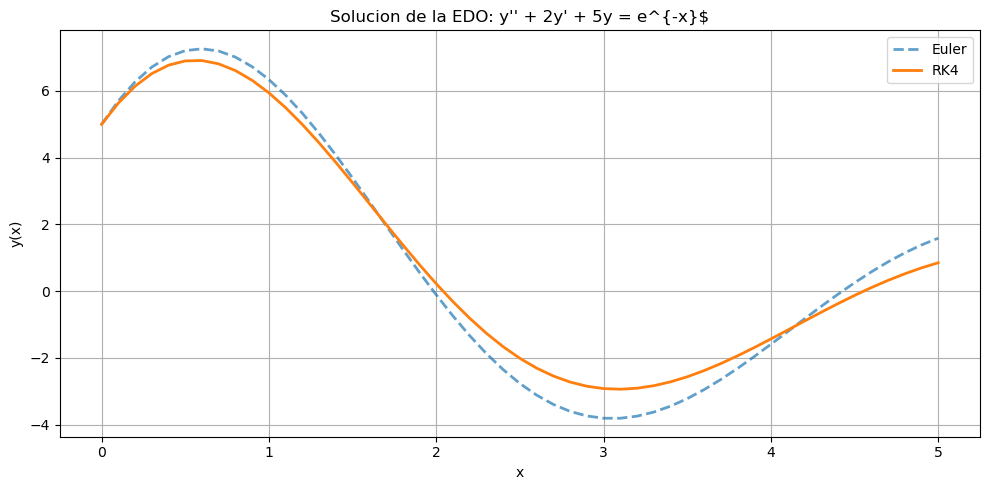

Valor final en x=5.0:
  Euler: y(5.0) = 1.586436
  RK4:   y(5.0) = 0.850442


In [5]:
# Graficas comparativas
plt.figure(figsize=(10, 5))

plt.plot(x_vals, y_euler, "--", label="Euler", alpha=0.7, lw=2)
plt.plot(x_vals, y_rk4, "-", label="RK4", lw=2)

plt.title("Solucion de la EDO: y'' + 2y' + 5y = e^{-x}$")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Valor final en x={xf}:")
print(f"  Euler: y({xf}) = {y_euler[-1]:.6f}")
print(f"  RK4:   y({xf}) = {y_rk4[-1]:.6f}")